In [2]:
import numpy as np
import miepython
import matplotlib.pyplot as plt

In [3]:
auData = np.genfromtxt("https://refractiveindex.info/tmp/database/data-nk/main/Au/Johnson.txt", delimiter = '\t')
N = len(auData)//2
waveLength = auData[1:N,0]
realRefractiveInd = auData[1:N,1]
imRefractiveInd = - auData[N+1:,1] #refractive index va negativo
refractiveIndex = realRefractiveInd + 1.0j*imRefractiveInd

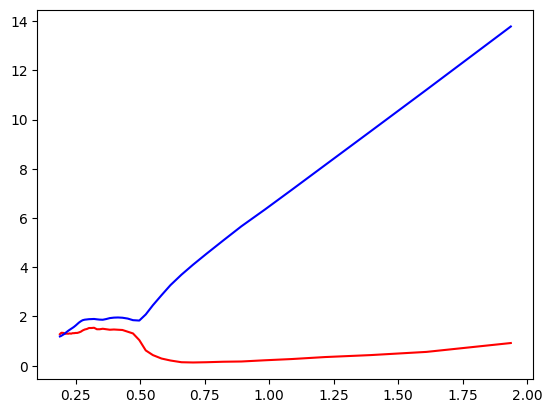

In [4]:
plt.plot(waveLength, realRefractiveInd, "red")
plt.plot(waveLength, - imRefractiveInd, "blue")
plt.show()

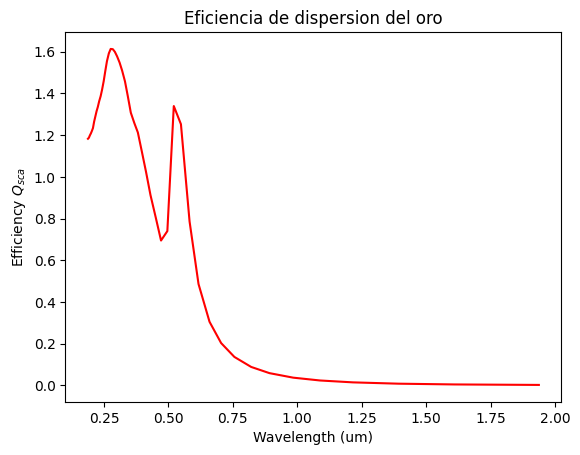

In [5]:
diameter = 0.1 #um ... 100nm diameter
qext, qsca, qback, g = miepython.efficiencies(
    refractiveIndex, diameter, waveLength)
# plt.plot(waveLength, qsca*(4*np.pi*diameter**2), color='red')
plt.plot(waveLength, qsca, color='red')
plt.xlabel("Wavelength (um)")
plt.ylabel("Efficiency $Q_{sca}$")
plt.title("Eficiencia de dispersion del oro")
plt.show()

In [ ]:
theta = np.linspace(180,-180,180)*np.pi/180.0
mu = np.cos(theta)

# i want to find the index for 1.61 um
index = np.where(waveLength == 0.6168)[0][0]
diameter = 1.6
sizeParameter = np.pi*diameter/waveLength #sP = 2pi d/2 /lambda
scatteredIntensity = miepython.i_unpolarized(refractiveIndex[index],sizeParameter[index], mu)
plt.polar(theta, scatteredIntensity*40)
print(qext[index], qsca[index], qback[index], g[index])

IndexError: index 0 is out of bounds for axis 0 with size 0

49
0 30.36805128710335


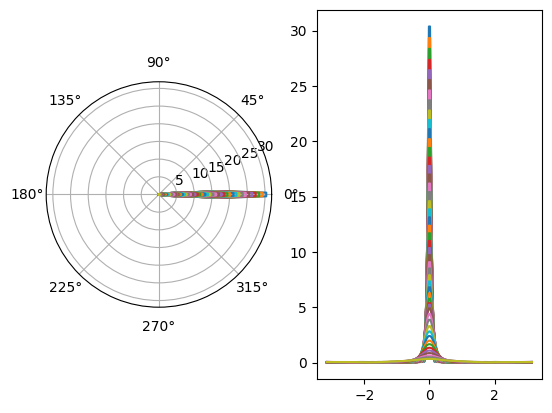

In [7]:
maxVal = 0
print(len(waveLength))
ax=plt.subplot(121, projection='polar')
for i in range(len(waveLength)):
    scatteredIntensity = miepython.i_unpolarized(refractiveIndex[i],sizeParameter[i], mu)
    plt.subplot(121, projection='polar')
    plt.plot(theta, scatteredIntensity)
    plt.subplot(122)
    plt.plot(theta, scatteredIntensity)
    if max(scatteredIntensity)>maxVal:
        maxVal = max(max(scatteredIntensity), maxVal)
        index = i
print(index, maxVal)



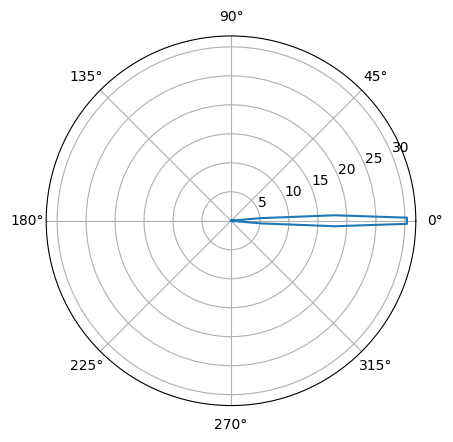

In [8]:
maxScatteredIntensity = miepython.i_unpolarized(refractiveIndex[index],sizeParameter[index], mu)
plt.polar(theta, maxScatteredIntensity)